# Task 2 — Step 5: Common Evaluation and Alignment Diagnostic

All four checkpoints (Source-only, DAN, DANN, CDAN) were fixed in notebooks 1–4 using source-validation macro-F1 only. This notebook is the **final** evaluation stage, and the only place Sketch labels enter a cross-method comparison.

**Domain-separability score (manual).** Freeze each backbone and collect equal numbers of source-validation and Sketch features (1,213 each: the full source-validation pool and a seeded Sketch subsample). Using a seeded (6304) stratified 70/30 split, train a balanced logistic regression (C = 1) to predict source vs target. Held-out accuracy = separability; **50% = chance**. Features are standardised on the training split, because the methods' feature norms differ by ~5× and would otherwise change what C = 1 means.

A lower score means domain identity is harder to recover. It does **not** by itself mean class information was preserved, so every separability number is read next to target recognition and per-class behaviour.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.manifold import TSNE

from shared.src.seed import set_seed, SEED
from shared.src.pacs_data import PACSDataset, get_pacs_dataloaders, PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.plotting import use_style, SEQ_CMAP, DIV_CMAP, PALETTE, DOMAIN_COLORS, NEUTRAL, INK_2, color_of, save_show, bar_labels
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from task2_domain_adaptation.src.evaluate import collect_outputs, domain_separability_from_features

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
CKPT = os.path.join(ROOT, 'task2_domain_adaptation', 'checkpoints')
RES = os.path.join(ROOT, 'task2_domain_adaptation', 'results')
METHODS = {'Source-only': 'source_only', 'DAN': 'dan', 'DANN': 'dann', 'CDAN': 'cdan'}
_, src_val, _, tgt_eval = get_pacs_dataloaders(DATA, SPLIT, eval_batch_size=64)

## 1. Collect every model's outputs once

In [2]:
outs = {}
for name, key in METHODS.items():
    m = ResNet18Backbone(num_classes=7).to(device)
    m.load_state_dict(torch.load(os.path.join(CKPT, f'{key}.pth'), map_location=device, weights_only=True))
    o = {d: collect_outputs(m, src_val[d], device) for d in PACS_SOURCE_DOMAINS}
    o['sketch'] = collect_outputs(m, tgt_eval, device)
    outs[name] = o
    print(f'{name}: collected source-val + Sketch logits/features')
hists = {name: json.load(open(os.path.join(CKPT, f'{key}_history.json'))) for name, key in METHODS.items()}

Source-only: collected source-val + Sketch logits/features
DAN: collected source-val + Sketch logits/features
DANN: collected source-val + Sketch logits/features
CDAN: collected source-val + Sketch logits/features


## 2. Main comparison table

In [3]:
def metrics(logits, y):
    p = logits.argmax(1); return 100 * (p == y).mean(), 100 * f1_score(y, p, average='macro')

rows = []
for name, o in outs.items():
    r = {'Method': name}
    for d in PACS_SOURCE_DOMAINS:
        r[f'{d} acc'], r[f'{d} F1'] = metrics(o[d][0], o[d][2])
    r['mean src acc'] = np.mean([r[f'{d} acc'] for d in PACS_SOURCE_DOMAINS])
    r['mean src F1'] = np.mean([r[f'{d} F1'] for d in PACS_SOURCE_DOMAINS])
    r['Sketch acc'], r['Sketch F1'] = metrics(o['sketch'][0], o['sketch'][2])
    src_feats = np.concatenate([o[d][1] for d in PACS_SOURCE_DOMAINS])
    r['domain separability'] = 100 * domain_separability_from_features(src_feats, o['sketch'][1], seed=SEED)['domain_separability']
    r['selected epoch'] = hists[name]['best_epoch']
    rows.append(r)
table = pd.DataFrame(rows).set_index('Method')
table.insert(table.columns.get_loc('Sketch F1') + 1, 'Δ Sketch acc vs SO', table['Sketch acc'] - table.loc['Source-only', 'Sketch acc'])
table.to_csv(os.path.join(RES, 'task2_main_table.csv'))
table.round(2)

,photo acc,photo F1,art_painting acc,art_painting F1,cartoon acc,cartoon F1,mean src acc,mean src F1,Sketch acc,Sketch F1,Δ Sketch acc vs SO,domain separability,selected epoch
Method,,,,,,,,,,,,,
Source-only,96.71,96.28,91.46,91.35,93.18,93.64,93.78,93.76,59.23,66.06,0.00,99.86,8
DAN,97.31,96.99,91.22,91.29,94.03,94.45,94.18,94.24,65.49,60.95,6.26,81.46,14
DANN,95.81,95.09,90.49,90.75,94.88,95.32,93.73,93.72,45.76,49.99,-13.46,100.00,12
CDAN,94.91,94.01,89.27,88.98,93.82,94.30,92.67,92.43,51.97,46.99,-7.25,98.21,6


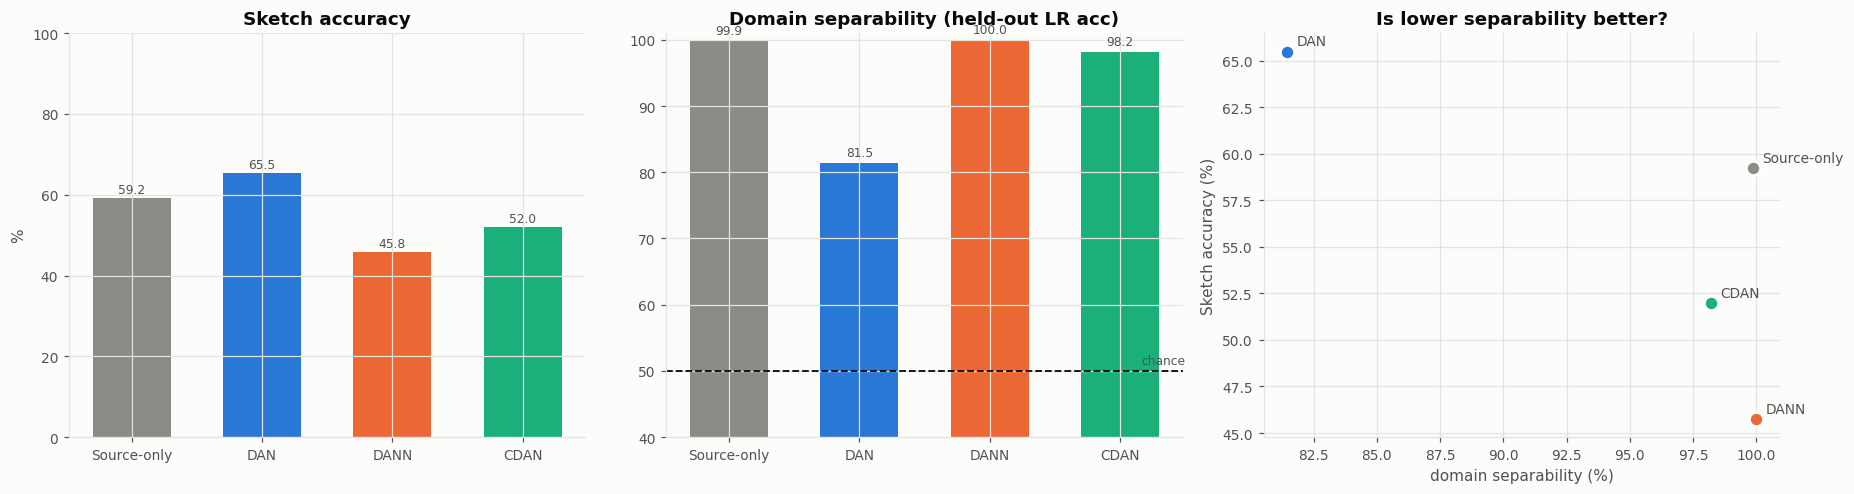

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
names = list(table.index); x = np.arange(len(names)); cols = [color_of(n) for n in names]
b = ax[0].bar(x, table['Sketch acc'], 0.6, color=cols); bar_labels(ax[0], b)
ax[0].set_xticks(x); ax[0].set_xticklabels(names); ax[0].set_ylabel('%'); ax[0].set_ylim(0, 100); ax[0].set_title('Sketch accuracy')
b = ax[1].bar(x, table['domain separability'], 0.6, color=cols); bar_labels(ax[1], b)
ax[1].axhline(50, color='#0b0b0b', ls='--', lw=1.2); ax[1].text(len(names) - 0.5, 51, 'chance', ha='right', fontsize=8, color=INK_2)
ax[1].set_xticks(x); ax[1].set_xticklabels(names); ax[1].set_ylim(40, 101); ax[1].set_title('Domain separability (held-out LR acc)')
for n in names:
    ax[2].scatter(table.loc[n, 'domain separability'], table.loc[n, 'Sketch acc'], s=90, color=color_of(n), edgecolor='white', linewidth=2, zorder=3)
    ax[2].annotate(n, (table.loc[n, 'domain separability'], table.loc[n, 'Sketch acc']), xytext=(6, 4), textcoords='offset points', fontsize=9, color=INK_2)
ax[2].set_xlabel('domain separability (%)'); ax[2].set_ylabel('Sketch accuracy (%)'); ax[2].set_title('Is lower separability better?')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task2_benchmark_summary.png'))

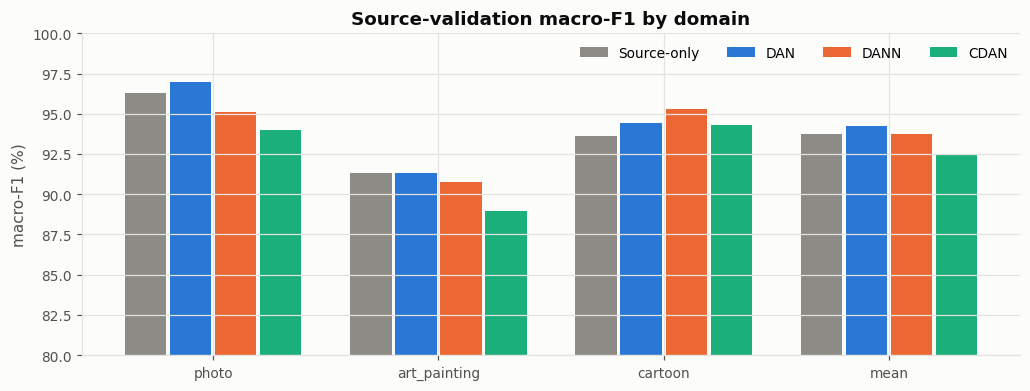

In [5]:
# Source side, per domain, before the mean (manual: report each source validation domain)
fig, ax = plt.subplots(figsize=(11, 3.8))
w = 0.2
for i, n in enumerate(names):
    vals = [table.loc[n, f'{d} F1'] for d in PACS_SOURCE_DOMAINS] + [table.loc[n, 'mean src F1']]
    bb = ax.bar(np.arange(4) + (i - 1.5) * w, vals, w * 0.92, color=color_of(n), label=n)
ax.set_xticks(range(4)); ax.set_xticklabels(PACS_SOURCE_DOMAINS + ['mean']); ax.set_ylim(80, 100); ax.set_ylabel('macro-F1 (%)')
ax.set_title('Source-validation macro-F1 by domain'); ax.legend(ncol=4)
save_show(fig, os.path.join(RES, 'task2_source_val_by_domain.png'))

## 3. Did each method train as intended? (curves side by side)
Classification loss, alignment term, and the label-free target diagnostics logged during training. DANN and CDAN share an axis for domain loss (ln 2 = a discriminator at chance); DAN's MMD² gets its own panel because it is on a different scale.

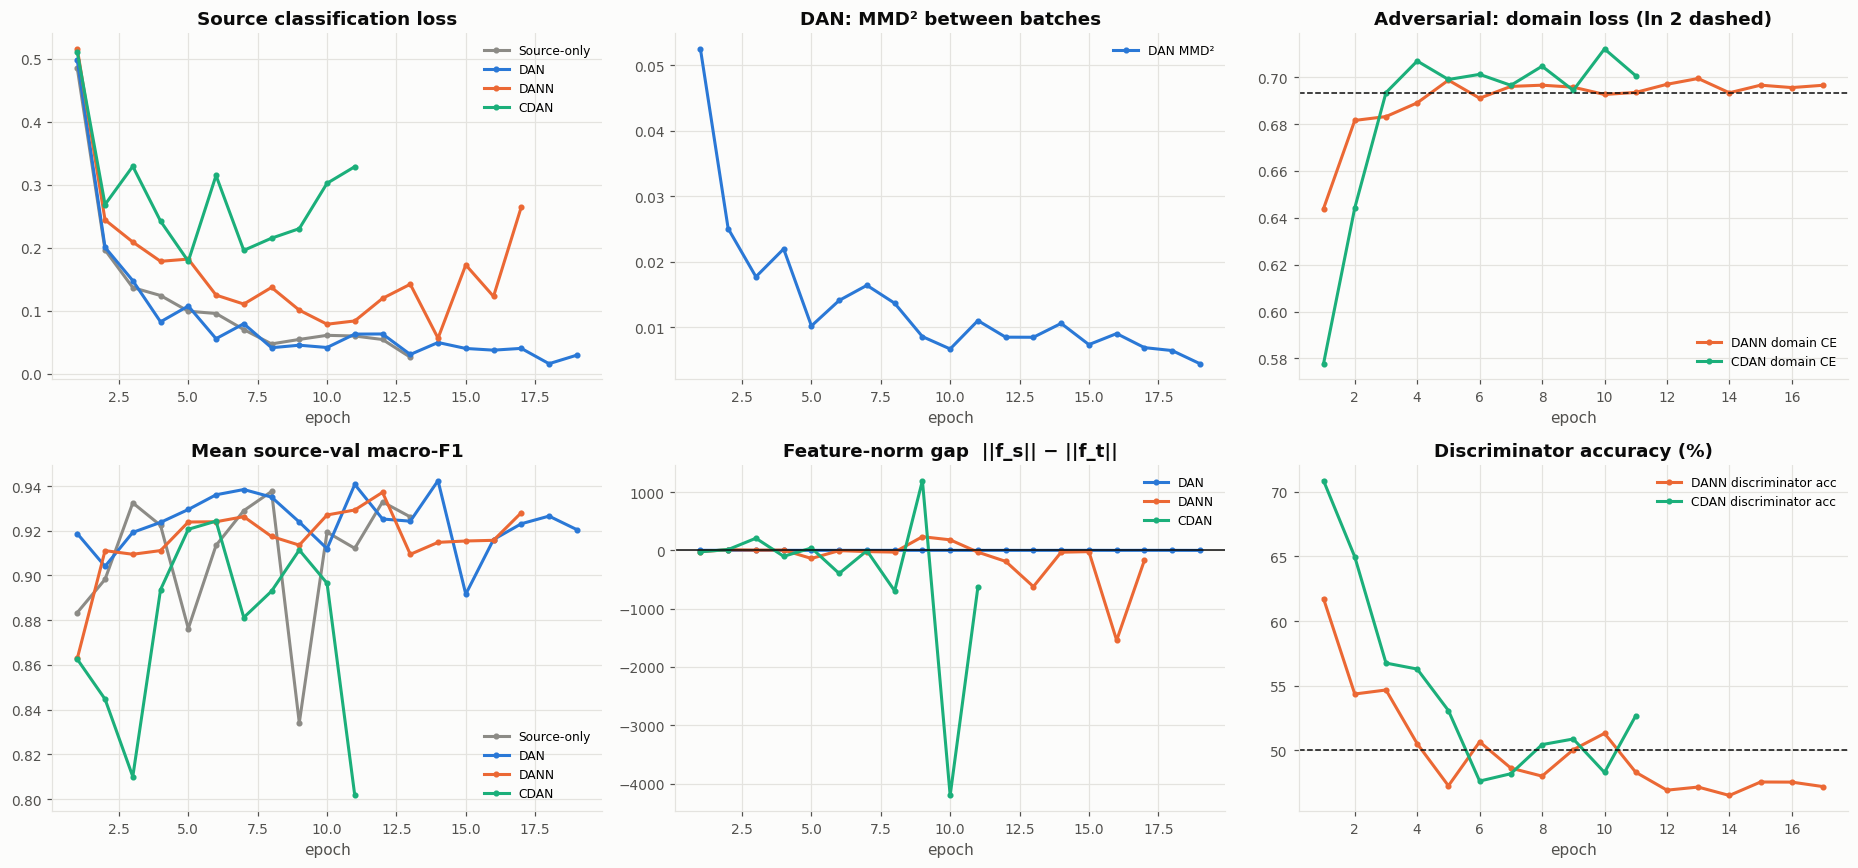

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(17, 8))
for n in names:
    H = hists[n]['history']; e = np.arange(1, len(H['cls_loss']) + 1); c = color_of(n)
    ax[0, 0].plot(e, H['cls_loss'], 'o-', ms=3, color=c, label=n)
    ax[1, 0].plot(e, H['val_mean_f1'], 'o-', ms=3, color=c, label=n)
    if n == 'DAN':
        ax[0, 1].plot(e, H['align_loss'], 'o-', ms=3, color=c, label='DAN MMD²')
    if n in ('DANN', 'CDAN'):
        ax[0, 2].plot(e, H['align_loss'], 'o-', ms=3, color=c, label=f'{n} domain CE')
        ax[1, 2].plot(e, 100 * np.array(H['dom_acc']), 'o-', ms=3, color=c, label=f'{n} discriminator acc')
    if n != 'Source-only':
        ax[1, 1].plot(e, np.array(H['src_feat_norm']) - np.array(H['tgt_feat_norm']), 'o-', ms=3, color=c, label=n)
ax[0, 2].axhline(np.log(2), color='#0b0b0b', ls='--', lw=1); ax[1, 2].axhline(50, color='#0b0b0b', ls='--', lw=1)
ax[1, 1].axhline(0, color='#0b0b0b', lw=1)
titles = [['Source classification loss', 'DAN: MMD² between batches', 'Adversarial: domain loss (ln 2 dashed)'],
          ['Mean source-val macro-F1', 'Feature-norm gap  ||f_s|| − ||f_t||', 'Discriminator accuracy (%)']]
for i in range(2):
    for j in range(3):
        ax[i, j].set_title(titles[i][j]); ax[i, j].set_xlabel('epoch'); ax[i, j].legend(fontsize=8)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task2_training_curves_all.png'))

## 4. Per-class Sketch accuracy and transfer relative to Source-only

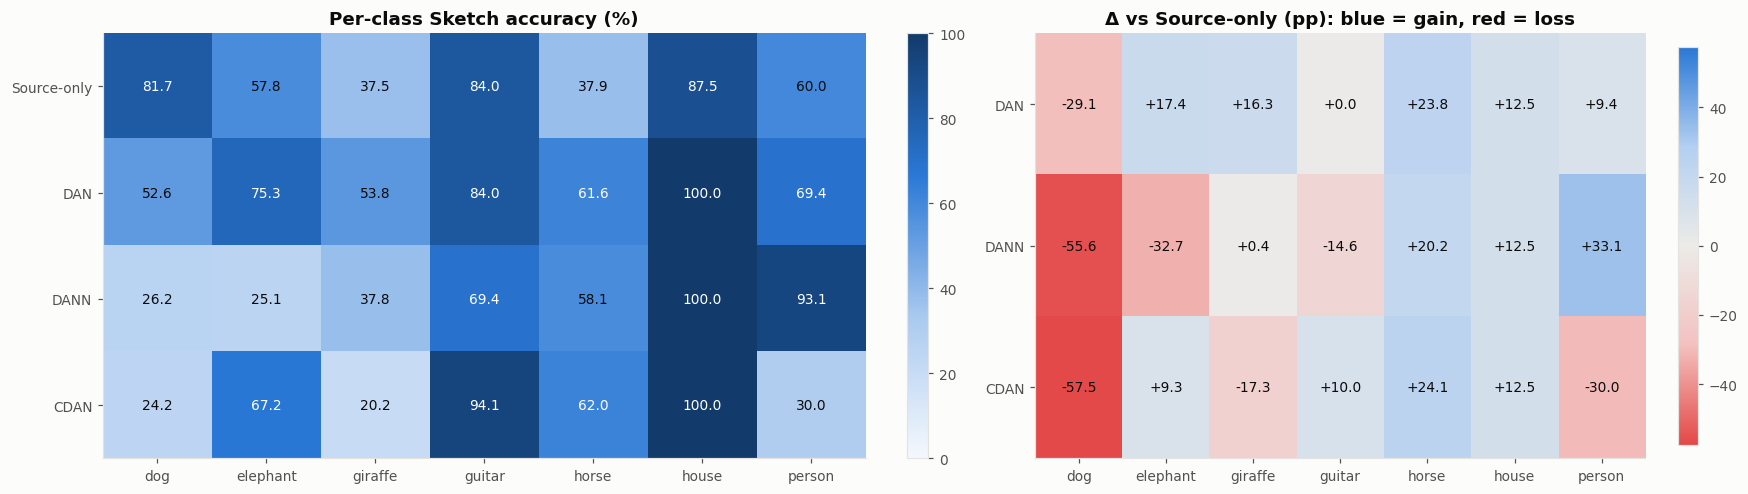

In [7]:
y_t = outs['Source-only']['sketch'][2]
pc = pd.DataFrame({n: [100 * (outs[n]['sketch'][0].argmax(1)[y_t == c] == c).mean() for c in range(7)] for n in names}, index=PACS_CLASSES)
delta = pc.drop(columns='Source-only').sub(pc['Source-only'], axis=0)
pc.to_csv(os.path.join(RES, 'task2_per_class_target.csv')); delta.to_csv(os.path.join(RES, 'task2_per_class_delta.csv'))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 4.6), gridspec_kw={'width_ratios': [1.25, 1]})
im = a1.imshow(pc.T.values, cmap=SEQ_CMAP, vmin=0, vmax=100, aspect='auto')
for i in range(len(names)):
    for j in range(7):
        v = pc.T.values[i, j]; a1.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=9, color='white' if v > 60 else '#0b0b0b')
a1.set_xticks(range(7)); a1.set_xticklabels(PACS_CLASSES); a1.set_yticks(range(len(names))); a1.set_yticklabels(names); a1.grid(False)
a1.set_title('Per-class Sketch accuracy (%)'); fig.colorbar(im, ax=a1, fraction=0.03)
lim = max(10, np.abs(delta.values).max())
im = a2.imshow(delta.T.values, cmap=DIV_CMAP, vmin=-lim, vmax=lim, aspect='auto')
for i in range(delta.shape[1]):
    for j in range(7):
        a2.text(j, i, f'{delta.T.values[i, j]:+.1f}', ha='center', va='center', fontsize=9, color='#0b0b0b')
a2.set_xticks(range(7)); a2.set_xticklabels(PACS_CLASSES); a2.set_yticks(range(delta.shape[1])); a2.set_yticklabels(delta.columns); a2.grid(False)
a2.set_title('Δ vs Source-only (pp): blue = gain, red = loss'); fig.colorbar(im, ax=a2, fraction=0.03)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task2_per_class_transfer.png'))

In [8]:
# Largest improvement / degradation per method and the dominant confusion of that class
rows = []
for n in delta.columns:
    cm = confusion_matrix(y_t, outs[n]['sketch'][0].argmax(1), labels=range(7)); cmn = cm / cm.sum(1, keepdims=True)
    cm0 = confusion_matrix(y_t, outs['Source-only']['sketch'][0].argmax(1), labels=range(7)); cmn0 = cm0 / cm0.sum(1, keepdims=True)
    for kind, cls in [('largest gain', delta[n].idxmax()), ('largest drop', delta[n].idxmin())]:
        c = PACS_CLASSES.index(cls)
        off = cmn[c].copy(); off[c] = -1; j = off.argmax()
        off0 = cmn0[c].copy(); off0[c] = -1; j0 = off0.argmax()
        rows.append({'method': n, 'kind': kind, 'class': cls, 'Δ acc (pp)': delta.loc[cls, n],
                     'dominant confusion (method)': f'{PACS_CLASSES[j]} ({cmn[c, j]:.2f})',
                     'dominant confusion (Source-only)': f'{PACS_CLASSES[j0]} ({cmn0[c, j0]:.2f})'})
pd.DataFrame(rows).set_index(['method', 'kind']).round(2)

class  Δ acc (pp) dominant confusion (method)  \
method kind                                                           
DAN    largest gain   horse       23.77               person (0.13)   
       largest drop     dog      -29.15               person (0.28)   
DANN   largest gain  person       33.12                house (0.06)   
       largest drop     dog      -55.57               person (0.55)   
CDAN   largest gain   horse       24.14                house (0.16)   
       largest drop     dog      -57.51               person (0.38)   

                    dominant confusion (Source-only)  
method kind                                           
DAN    largest gain                       dog (0.52)  
       largest drop                  elephant (0.13)  
DANN   largest gain                       dog (0.23)  
       largest drop                  elephant (0.13)  
CDAN   largest gain                       dog (0.52)  
       largest drop                  elephant (0.13)

## 5. Sketch confusion matrices

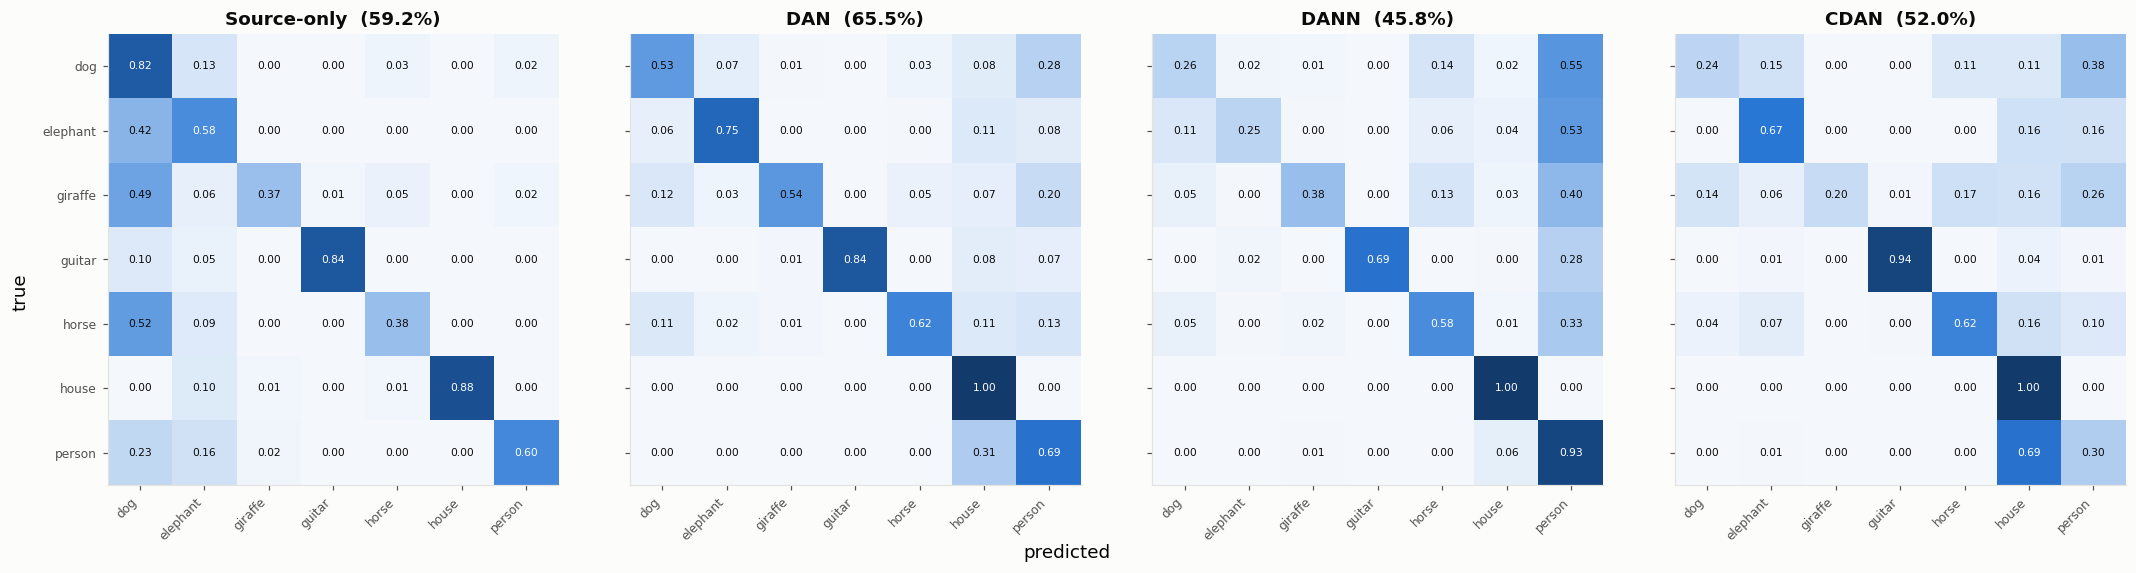

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, n in zip(axes, names):
    cm = confusion_matrix(y_t, outs[n]['sketch'][0].argmax(1), labels=range(7)); cmn = cm / cm.sum(1, keepdims=True)
    ax.imshow(cmn, cmap=SEQ_CMAP, vmin=0, vmax=1)
    for i in range(7):
        for j in range(7):
            ax.text(j, i, f'{cmn[i, j]:.2f}', ha='center', va='center', fontsize=7, color='white' if cmn[i, j] > 0.55 else '#0b0b0b')
    ax.set_xticks(range(7)); ax.set_xticklabels(PACS_CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(7)); ax.set_yticklabels(PACS_CLASSES if n == names[0] else [], fontsize=8); ax.grid(False)
    ax.set_title(f"{n}  ({table.loc[n, 'Sketch acc']:.1f}%)")
fig.supxlabel('predicted'); fig.supylabel('true'); fig.tight_layout()
save_show(fig, os.path.join(RES, 'task2_confusion_matrices.png'))

## 6. Positive and negative transfer, image by image
For each adaptation method: sketches that Source-only got **wrong** but the method got **right** (top row), and sketches Source-only got **right** that the method broke (bottom row). Samples are random with seed 6304.

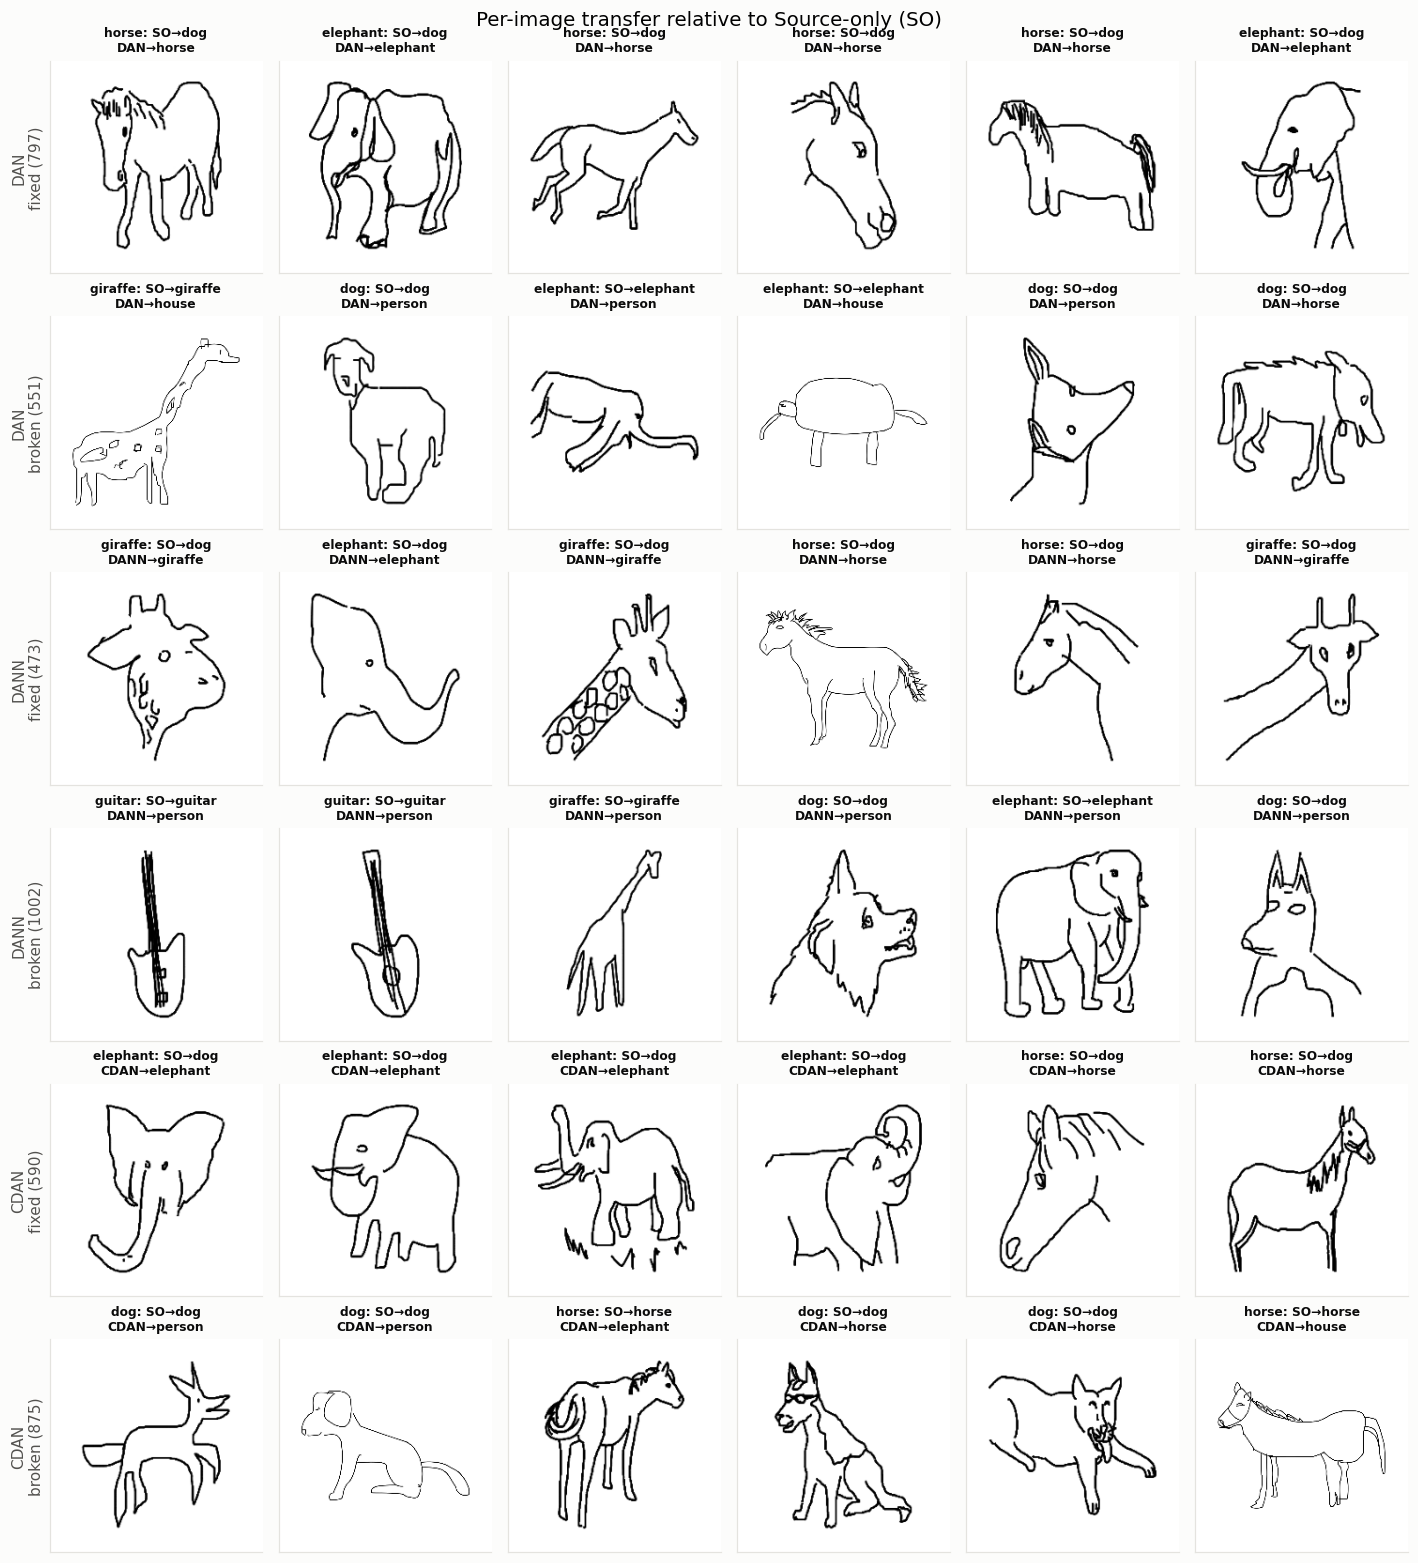

In [10]:
raw = PACSDataset(DATA, 'sketch')
p0 = outs['Source-only']['sketch'][0].argmax(1)
rng = np.random.RandomState(SEED)
fig, axes = plt.subplots(6, 6, figsize=(13, 14.5))
for r, n in enumerate(['DAN', 'DANN', 'CDAN']):
    pn = outs[n]['sketch'][0].argmax(1)
    fixed, broken = np.where((p0 != y_t) & (pn == y_t))[0], np.where((p0 == y_t) & (pn != y_t))[0]
    for k, (pool, tag) in enumerate([(fixed, 'fixed'), (broken, 'broken')]):
        pick = rng.choice(pool, min(6, len(pool)), replace=False) if len(pool) else []
        for c in range(6):
            ax = axes[2 * r + k, c]; ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            if c < len(pick):
                i = int(pick[c]); ax.imshow(raw[i][0])
                ax.set_title(f'{PACS_CLASSES[y_t[i]]}: SO→{PACS_CLASSES[p0[i]]}\n{n}→{PACS_CLASSES[pn[i]]}', fontsize=8)
        axes[2 * r + k, 0].set_ylabel(f'{n}\n{tag} ({len(pool)})', fontsize=10)
fig.suptitle('Per-image transfer relative to Source-only (SO)', fontsize=13); fig.tight_layout()
save_show(fig, os.path.join(RES, 'task2_transfer_examples.png'))

## 7. Joint t-SNE of source-validation and Sketch features
Per model: one t-SNE (perplexity 30, PCA init, seed 6304) fitted on 600 source-validation + 600 Sketch features, so both domains share one embedding. Top row: coloured by domain. Bottom row: coloured by class, with marker = domain. Coordinates are **not** comparable across columns (separate fits).

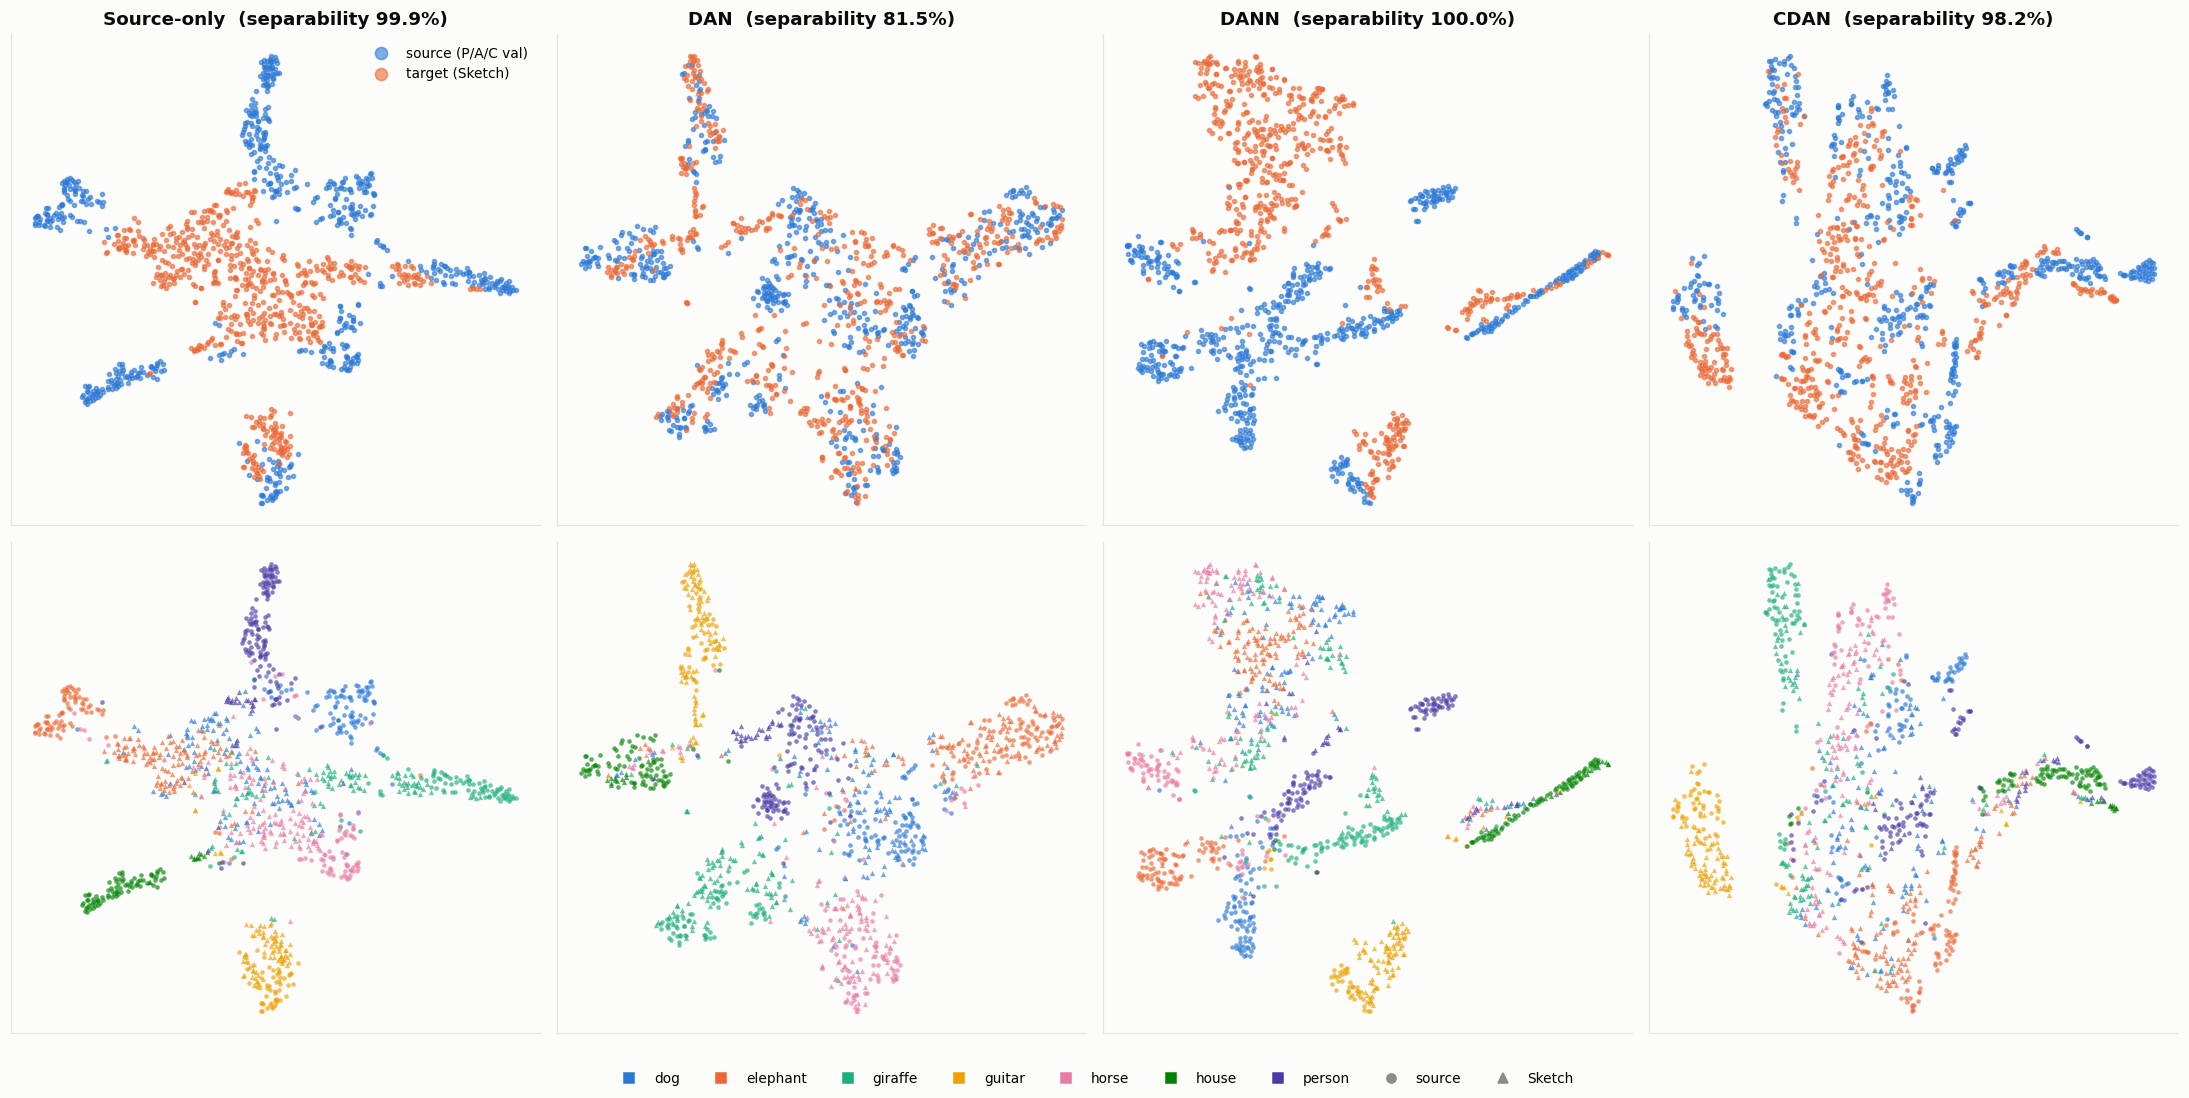

In [11]:
rng = np.random.RandomState(SEED)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
cls_cols = PALETTE[:7]
for j, n in enumerate(names):
    o = outs[n]
    fs = np.concatenate([o[d][1] for d in PACS_SOURCE_DOMAINS]); ys = np.concatenate([o[d][2] for d in PACS_SOURCE_DOMAINS])
    si = rng.choice(len(fs), 600, replace=False); ti = np.random.RandomState(SEED).choice(len(o['sketch'][1]), 600, replace=False)
    X = np.concatenate([fs[si], o['sketch'][1][ti]]); yy = np.concatenate([ys[si], o['sketch'][2][ti]]); dom = np.r_[np.zeros(600), np.ones(600)]
    E = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(X)
    for dv, lab in [(0, 'source'), (1, 'target')]:
        axes[0, j].scatter(E[dom == dv, 0], E[dom == dv, 1], s=7, alpha=0.6, color=DOMAIN_COLORS[lab], label=f'{lab} ({"P/A/C val" if dv == 0 else "Sketch"})')
    for c in range(7):
        for dv, mk in [(0, 'o'), (1, '^')]:
            s = (yy == c) & (dom == dv)
            axes[1, j].scatter(E[s, 0], E[s, 1], s=9 if dv == 0 else 12, marker=mk, alpha=0.65, color=cls_cols[c], linewidths=0)
    axes[0, j].set_title(f"{n}  (separability {table.loc[n, 'domain separability']:.1f}%)")
    for i in range(2): axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
axes[0, 0].legend(markerscale=3, loc='best')
handles = [Line2D([], [], ls='', marker='s', color=cls_cols[c], label=PACS_CLASSES[c]) for c in range(7)]
handles += [Line2D([], [], ls='', marker='o', color=NEUTRAL, label='source'), Line2D([], [], ls='', marker='^', color=NEUTRAL, label='Sketch')]
fig.legend(handles=handles, loc='lower center', ncol=9, frameon=False)
fig.tight_layout(rect=[0, 0.04, 1, 1]); save_show(fig, os.path.join(RES, 'task2_tsne_alignment.png'))

## 8. Evidence for Research Questions 2 and 3
Facts only; the interpretation belongs in the report.

In [12]:
print('RQ2: separability vs Sketch recognition')
for n in names:
    print(f"  {n:12s} separability {table.loc[n, 'domain separability']:5.1f}% | Sketch acc {table.loc[n, 'Sketch acc']:5.1f}% "
          f"(Δ {table.loc[n, 'Δ Sketch acc vs SO']:+5.1f}) | mean src F1 {table.loc[n, 'mean src F1']:5.1f}%")
rank_sep = table['domain separability'].rank().astype(int).to_dict(); rank_acc = table['Sketch acc'].rank(ascending=False).astype(int).to_dict()
print('  rank by lowest separability:', sorted(rank_sep, key=rank_sep.get)); print('  rank by highest Sketch acc:  ', sorted(rank_acc, key=rank_acc.get))
print('  classes with negative transfer (Δ < 0):', {n: [c for c in PACS_CLASSES if delta.loc[c, n] < 0] for n in delta.columns})
print('\nRQ3: class-conditional (CDAN) vs marginal (DAN, DANN)')
for n in ['DAN', 'DANN']:
    d = pc['CDAN'] - pc[n]
    print(f"  CDAN − {n}: overall {table.loc['CDAN', 'Sketch acc'] - table.loc[n, 'Sketch acc']:+.1f} pp | classes where CDAN better: {list(d[d > 0].index)}")

RQ2: separability vs Sketch recognition
  Source-only  separability  99.9% | Sketch acc  59.2% (Δ  +0.0) | mean src F1  93.8%
  DAN          separability  81.5% | Sketch acc  65.5% (Δ  +6.3) | mean src F1  94.2%
  DANN         separability 100.0% | Sketch acc  45.8% (Δ -13.5) | mean src F1  93.7%
  CDAN         separability  98.2% | Sketch acc  52.0% (Δ  -7.3) | mean src F1  92.4%
  rank by lowest separability: ['DAN', 'CDAN', 'Source-only', 'DANN']
  rank by highest Sketch acc:   ['DAN', 'Source-only', 'CDAN', 'DANN']
  classes with negative transfer (Δ < 0): {'DAN': ['dog'], 'DANN': ['dog', 'elephant', 'guitar'], 'CDAN': ['dog', 'giraffe', 'person']}

RQ3: class-conditional (CDAN) vs marginal (DAN, DANN)
  CDAN − DAN: overall -13.5 pp | classes where CDAN better: ['guitar', 'horse']
  CDAN − DANN: overall +6.2 pp | classes where CDAN better: ['elephant', 'guitar', 'horse']
